In [2]:
import pandas as pd

In [ ]:
df = pd.read_csv("../data/feature_matrix.csv")

X = df.drop(columns=["viral"])
y = df["viral"]

In [4]:
X.shape

(2091, 54)

In [5]:
y.value_counts()

viral
0    1568
1     523
Name: count, dtype: int64

In [6]:
for col in X.columns:
    print(col)

sentiment_numeric
confidence
title_length
title_word_count
title_has_number
title_has_question
title_has_exclaim
has_comments_text
hour
day_of_week
is_weekend
is_peak_hour
topic_confidence
topic_1
topic_2
topic_3
topic_4
topic_5
topic_6
topic_7
topic_8
topic_9
topic_10
topic_11
topic_12
topic_13
topic_14
topic_15
has_org_mention
org_mention_count
has_person_mention
flair_ADBLOCK WARNING
flair_Artificial Intelligence
flair_Biotechnology
flair_Business
flair_Comcast
flair_Crypto
flair_Energy
flair_Hardware
flair_Machine Learning
flair_Misleading
flair_Nanotech/Materials
flair_Net Neutrality
flair_Networking/Telecom
flair_Other
flair_Politics
flair_Privacy
flair_Robotics/Automation
flair_Security
flair_Social Media
flair_Society
flair_Software
flair_Space
flair_Transportation


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [9]:

X_train.shape

(1672, 54)

In [10]:

X_test.shape

(419, 54)

In [11]:

y_train.value_counts()

viral
0    1254
1     418
Name: count, dtype: int64

In [12]:

y_test.value_counts()

viral
0    314
1    105
Name: count, dtype: int64

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"{X_train_scaled.mean():.4f}")
print(f"{X_train_scaled.std():.4f}")

-0.0000
1.0000


In [15]:
!pip install xgboost

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=9229),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=9229),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=9229),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, eval_metric='logloss', random_state=9229)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=9229)


In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

In [19]:
for name, model in models.items():
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test
    X_cv = X_train_scaled if name == "Logistic Regression" else X_train
    cv_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    results[name] = {
        "model":      model,
        "y_pred":     y_pred,
        "y_pred_prob":y_pred_prob,
        "roc_auc":    roc_auc,
        "cv_mean":    cv_scores.mean(),
        "cv_std":     cv_scores.std()
    }
    print(f"\n{name}")
    print(f"   CV ROC AUC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"   Test ROC AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Viral", "Viral"]))


Logistic Regression
   CV ROC AUC  : 0.7867 ± 0.0176
   Test ROC AUC: 0.7833
              precision    recall  f1-score   support

   Not Viral       0.79      0.96      0.87       314
       Viral       0.70      0.25      0.37       105

    accuracy                           0.79       419
   macro avg       0.75      0.61      0.62       419
weighted avg       0.77      0.79      0.74       419


Random Forest
   CV ROC AUC  : 0.7725 ± 0.0312
   Test ROC AUC: 0.7767
              precision    recall  f1-score   support

   Not Viral       0.78      0.97      0.86       314
       Viral       0.67      0.19      0.30       105

    accuracy                           0.77       419
   macro avg       0.72      0.58      0.58       419
weighted avg       0.75      0.77      0.72       419


Gradient Boosting
   CV ROC AUC  : 0.7849 ± 0.0268
   Test ROC AUC: 0.7382
              precision    recall  f1-score   support

   Not Viral       0.79      0.95      0.86       314
       Vira

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

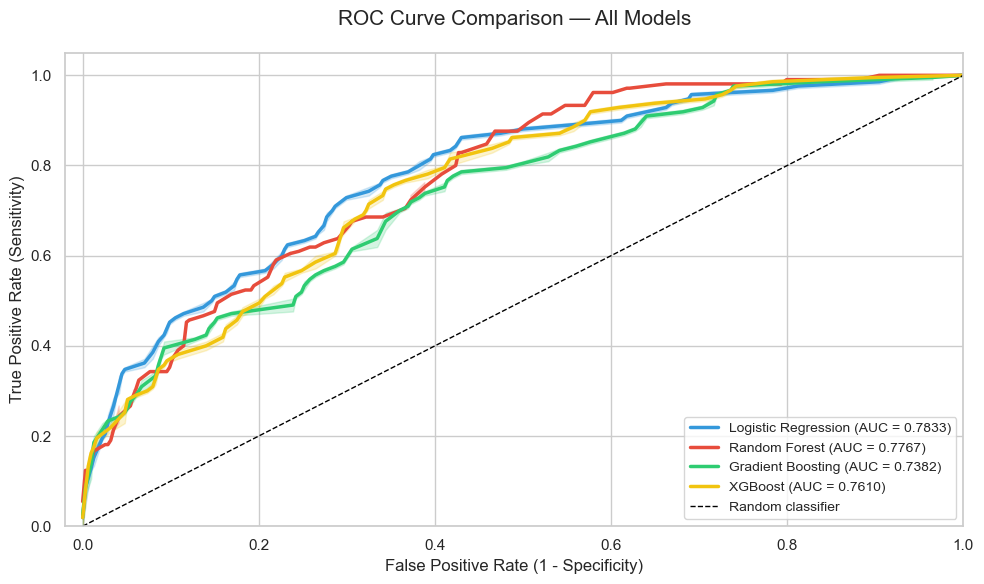

In [21]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f1c40f"]

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_prob"])

    
    sns.lineplot(x=fpr, y=tpr, color=color, linewidth=2.5, 
                 label=f"{name} (AUC = {res['roc_auc']:.4f})")
    
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label="Random classifier")


plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve Comparison — All Models", fontsize=15, pad=20)


plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

Best model: Logistic Regression
ROC AUC: 0.7833


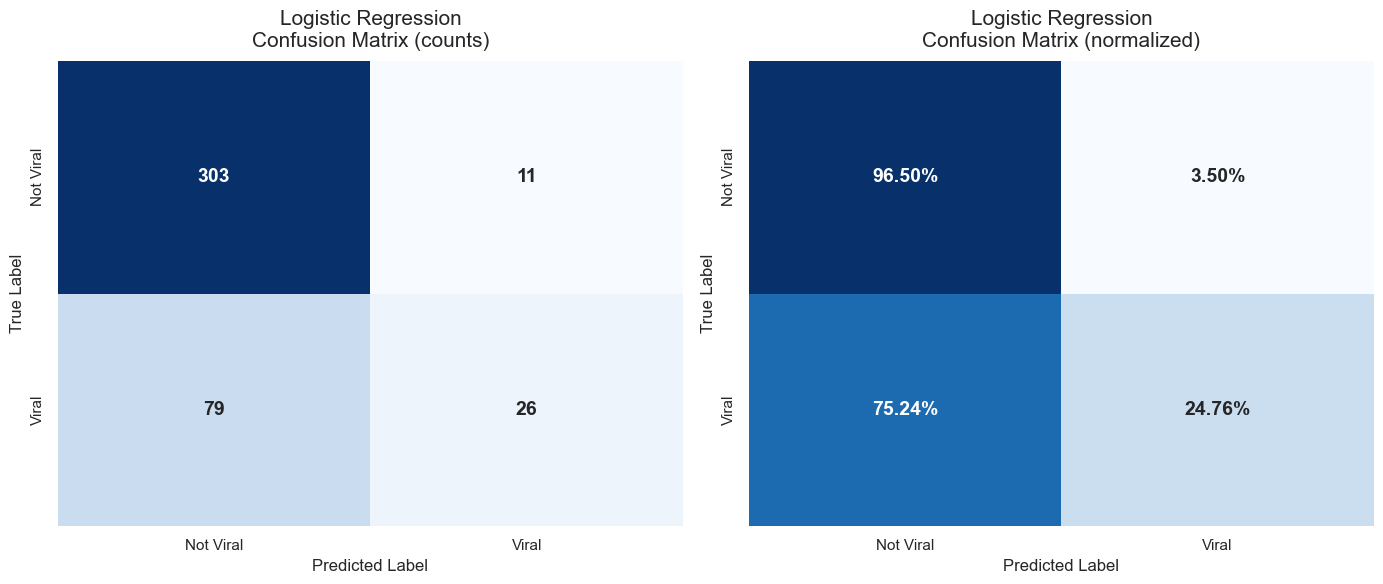

In [23]:
best_name = max(results, key=lambda x: results[x]["roc_auc"])
best      = results[best_name]

print(f"Best model: {best_name}")
print(f"ROC AUC: {best['roc_auc']:.4f}")
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, best["y_pred"])
cm_norm = confusion_matrix(y_test, best["y_pred"], normalize="true")
labels = ["Not Viral", "Viral"]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[0],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f"{best_name}\nConfusion Matrix (counts)", fontsize=15, pad=10)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f"{best_name}\nConfusion Matrix (normalized)", fontsize=15, pad=10)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()